In [7]:
joblib.dump(scaler, "../model/scaler.pkl")

print("Scaler Saved Successfully!")

NameError: name 'joblib' is not defined

In [ ]:
import joblib
joblib.dump(xgb_model, "../model/model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [ ]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0
2,KNN,1.0
3,XGBoost,1.0


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "KNN",
        "XGBoost"
    ],
    "Accuracy": [
        dt_accuracy,
        rf_accuracy,
        knn_accuracy,
        xgb_accuracy
    ]
})

results

,Model,Accuracy
0,Decision Tree,1.0
1,Random Forest,1.0
2,KNN,1.0
3,XGBoost,1.0


In [ ]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [ ]:
print(confusion_matrix(y_test, xgb_pred))

[[19]]


In [ ]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy :", xgb_accuracy)

XGBoost Accuracy : 1.0


In [ ]:
xgb_pred = xgb_model.predict(X_test)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
from xgboost import XGBClassifier

In [ ]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [ ]:
print(confusion_matrix(y_test, knn_pred))

[[19]]


In [ ]:
knn_accuracy = accuracy_score(y_test, knn_pred)

print("KNN Accuracy :", knn_accuracy)

KNN Accuracy : 1.0


In [ ]:
knn_pred = knn_model.predict(X_test_scaled)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [ ]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [ ]:
print(confusion_matrix(y_test, rf_pred))

[[19]]


In [ ]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", rf_accuracy)

Random Forest Accuracy : 1.0


In [ ]:
rf_pred = rf_model.predict(X_test)

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19

    accuracy                           1.00        19
   macro avg       1.00      1.00      1.00        19
weighted avg       1.00      1.00      1.00        19



In [ ]:
print(confusion_matrix(y_test, dt_pred))

[[19]]


In [ ]:
dt_accuracy = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy :", dt_accuracy)

Decision Tree Accuracy : 1.0


In [ ]:
dt_pred = dt_model.predict(X_test)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [ ]:
import joblib

joblib.dump(scaler, "../model/scaler.pkl")

['../model/scaler.pkl']

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (73, 10)
Testing Features  : (19, 10)
Training Labels   : (73,)
Testing Labels    : (19,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(X.shape)
print(y.shape)

(92, 10)
(92,)


In [ ]:
X = df.drop("flood", axis=1)

y = df["flood"]

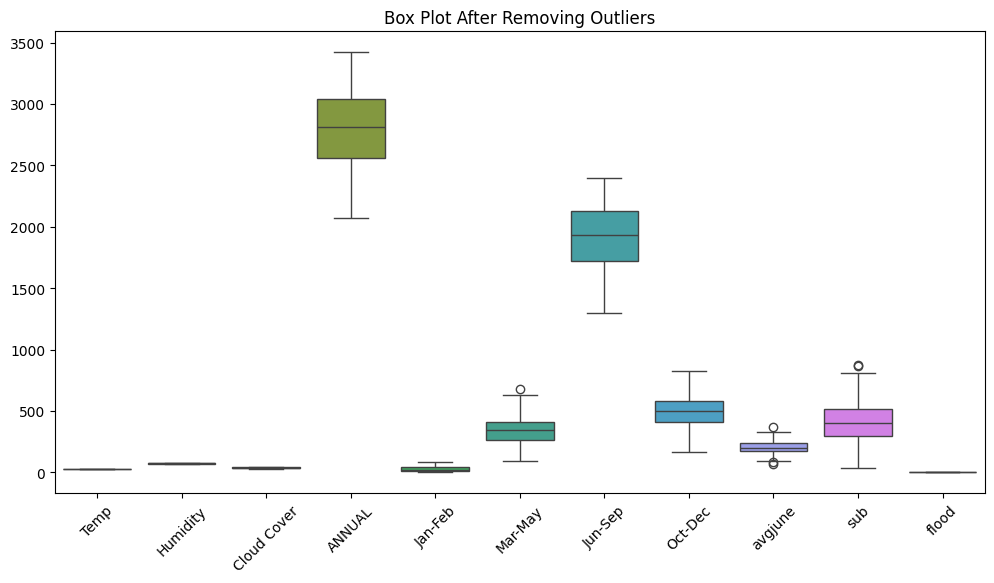

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.title("Box Plot After Removing Outliers")
plt.show()

In [ ]:
df.shape

(92, 11)

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [ ]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))

outliers.sum()

Temp            0
Humidity        0
Cloud Cover     0
ANNUAL          3
Jan-Feb         2
Mar-May         6
Jun-Sep         2
Oct-Dec         0
avgjune         0
sub             0
flood          16
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

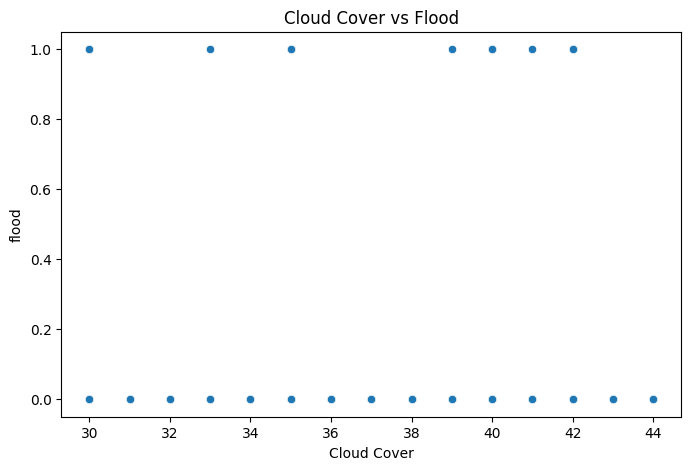

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Cloud Cover", y="flood", data=df)
plt.title("Cloud Cover vs Flood")
plt.show()

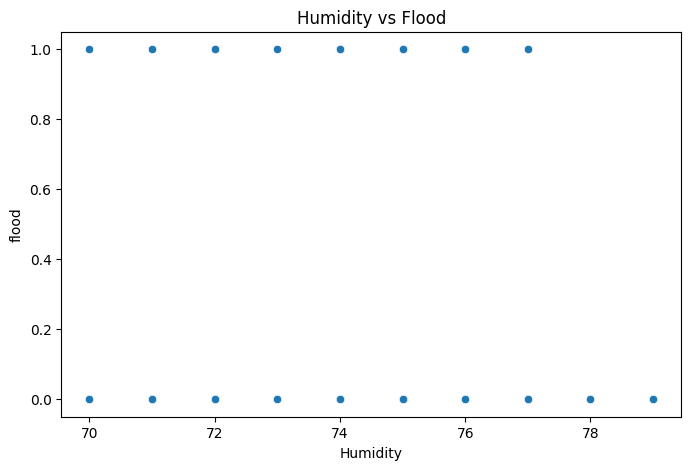

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="Humidity", y="flood", data=df)
plt.title("Humidity vs Flood")
plt.show()

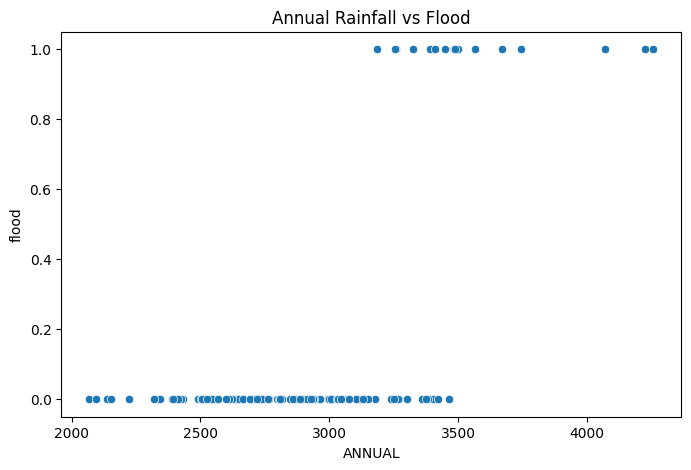

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="ANNUAL", y="flood", data=df)
plt.title("Annual Rainfall vs Flood")
plt.show()

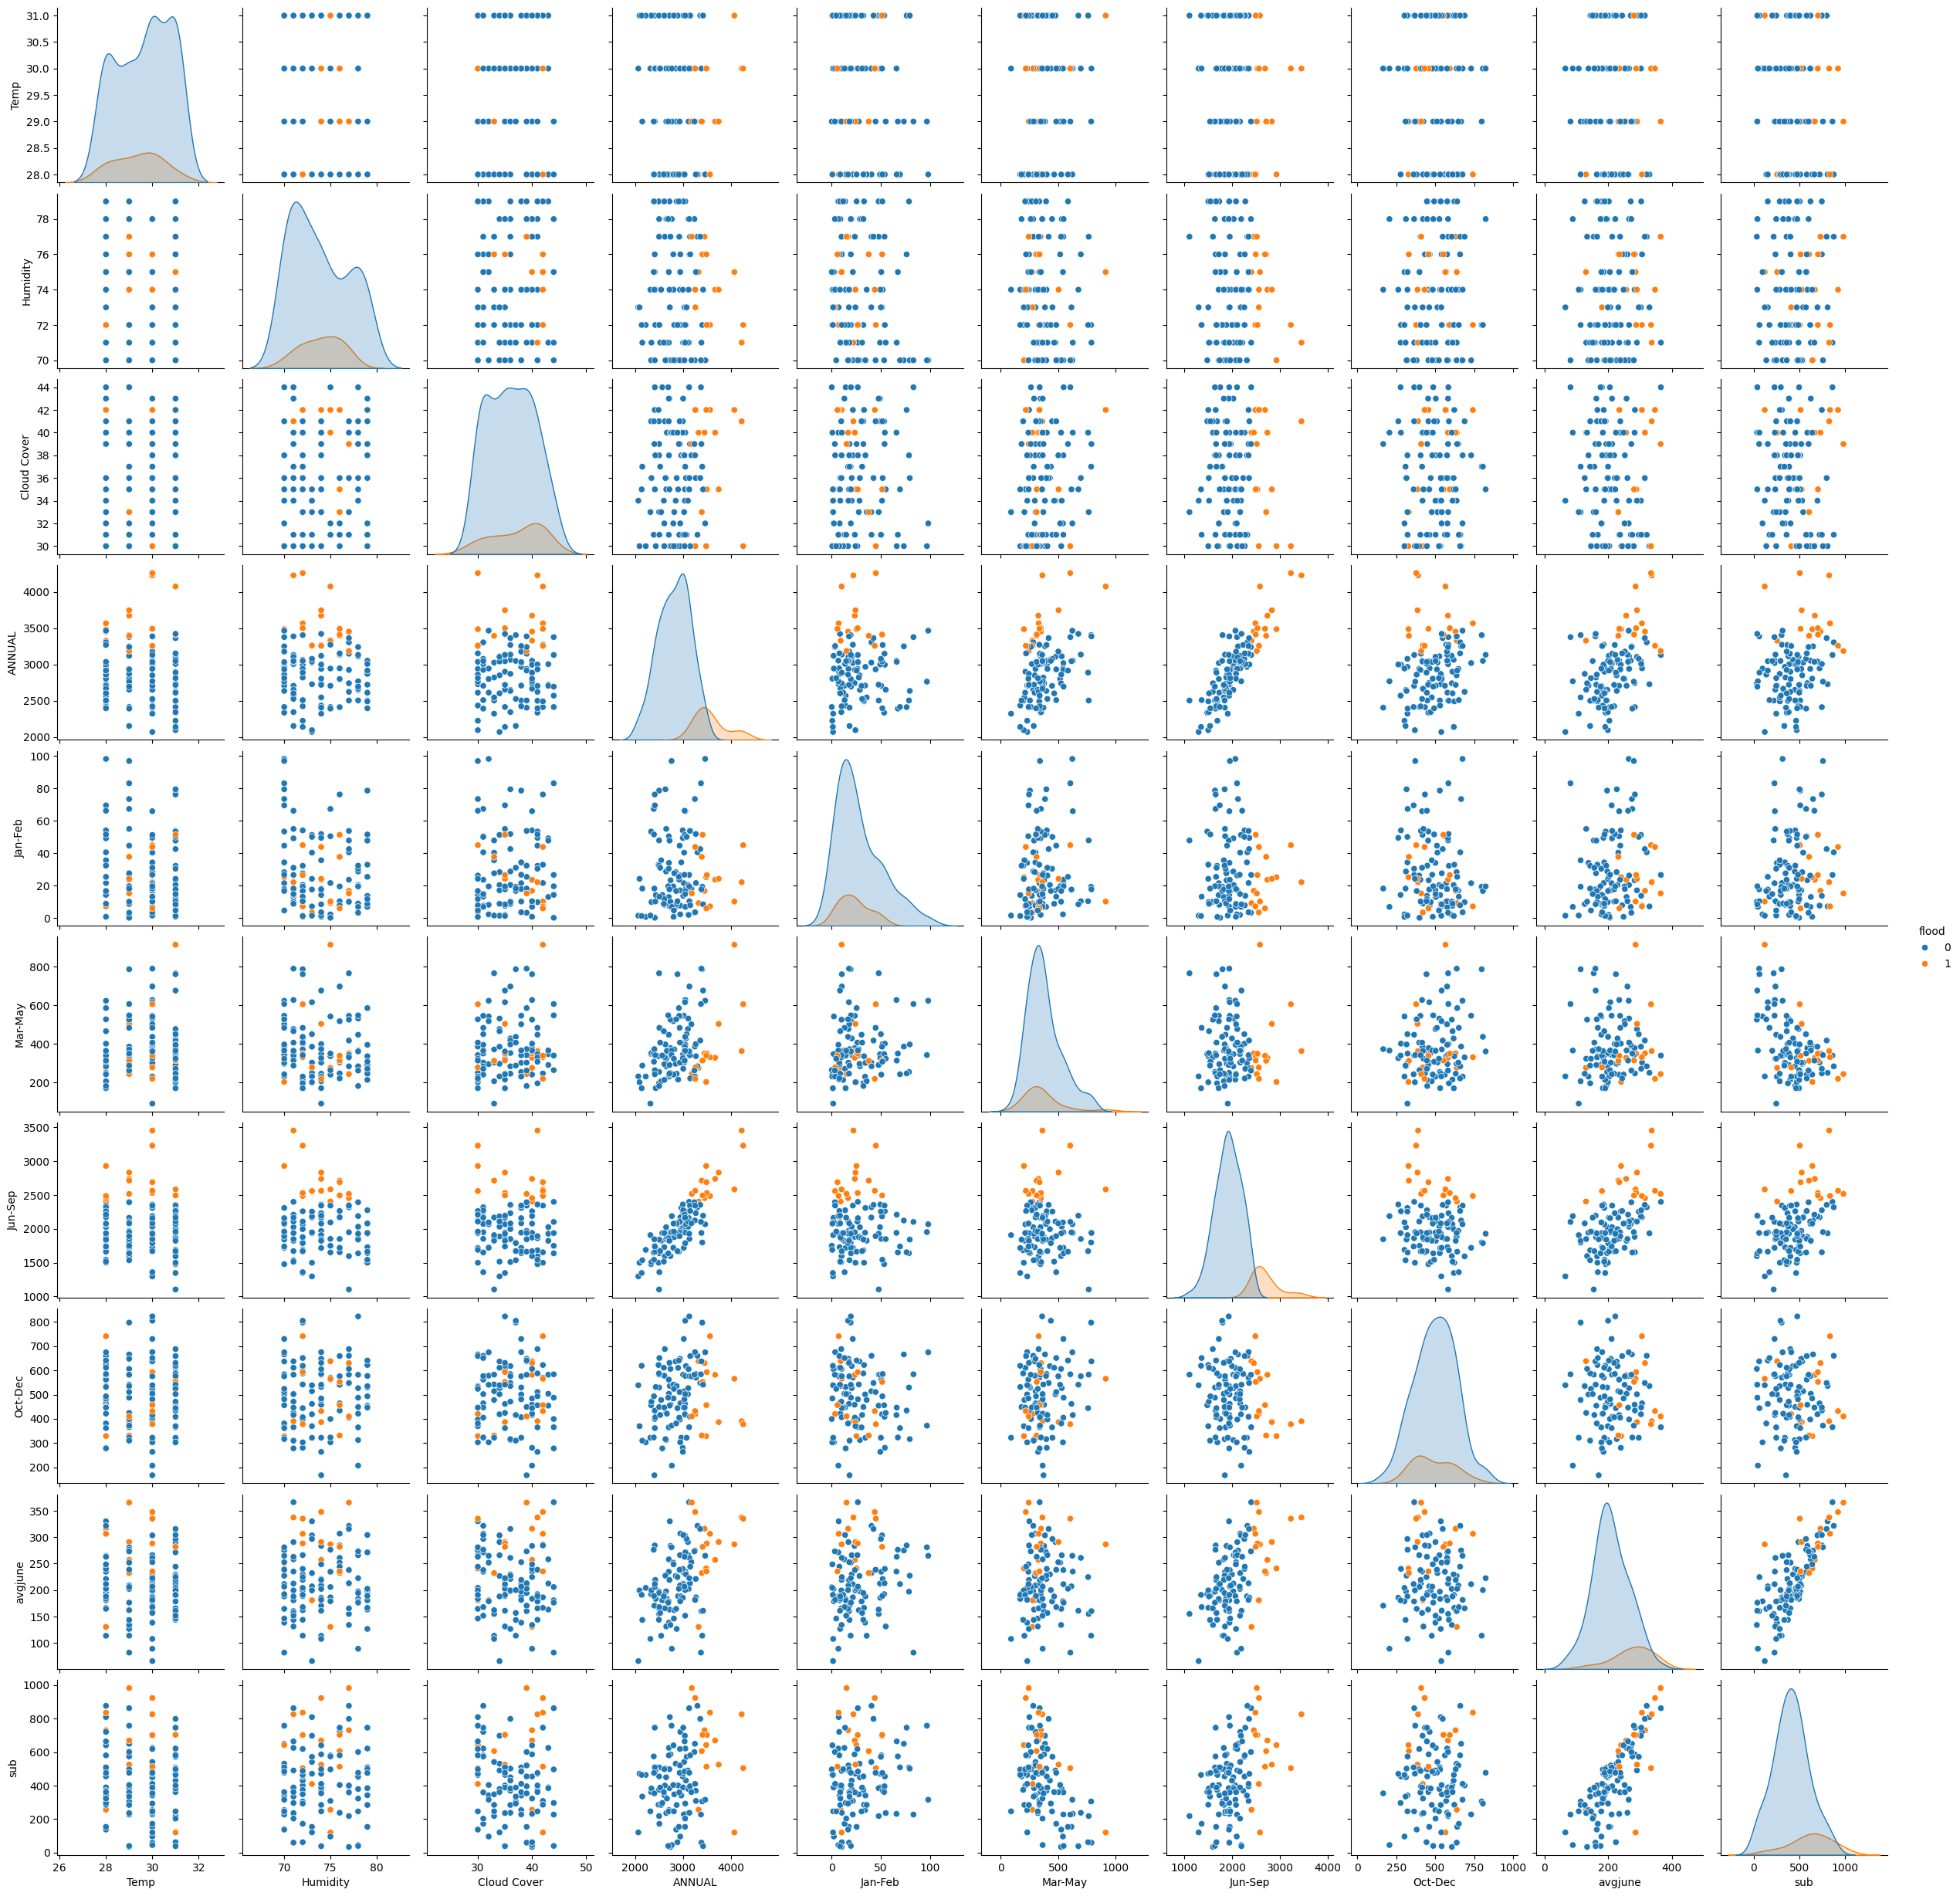

In [ ]:
sns.pairplot(df, hue="flood")
plt.show()

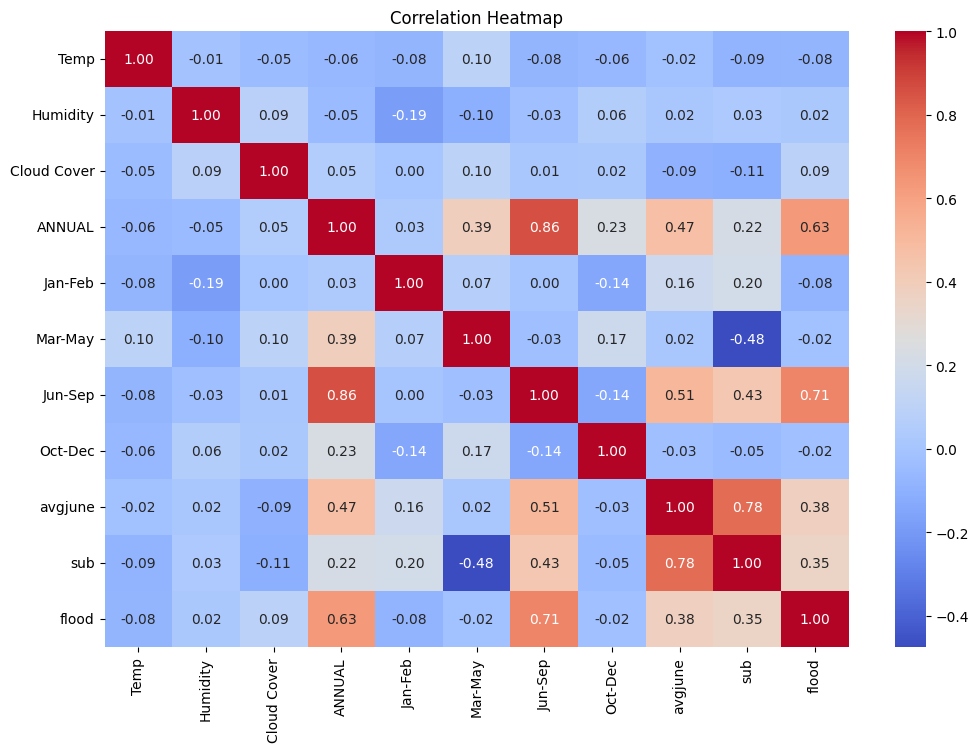

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
correlation = df.corr()
correlation

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
Temp,1.000000,-0.012727,-0.046568,-0.063014,-0.080076,0.099519,-0.081965,-0.063034,-0.019751,-0.088331,-0.080946
Humidity,-0.012727,1.000000,0.085824,-0.054767,-0.185965,-0.101232,-0.029583,0.059739,0.017656,0.029981,0.020250
Cloud Cover,-0.046568,0.085824,1.000000,0.051166,0.004376,0.096645,0.010833,0.020966,-0.089843,-0.106455,0.089801
ANNUAL,-0.063014,-0.054767,0.051166,1.000000,0.033639,0.387790,0.861190,0.232069,0.474644,0.220009,0.626874
Jan-Feb,-0.080076,-0.185965,0.004376,0.033639,1.000000,0.066479,0.001178,-0.143670,0.164691,0.201266,-0.084446
Mar-May,0.099519,-0.101232,0.096645,0.387790,0.066479,1.000000,-0.029007,0.171805,0.019183,-0.475750,-0.017598
Jun-Sep,-0.081965,-0.029583,0.010833,0.861190,0.001178,-0.029007,1.000000,-0.141467,0.511113,0.431997,0.705202
Oct-Dec,-0.063034,0.059739,0.020966,0.232069,-0.143670,0.171805,-0.141467,1.000000,-0.028055,-0.050862,-0.024852
avgjune,-0.019751,0.017656,-0.089843,0.474644,0.164691,0.019183,0.511113,-0.028055,1.000000,0.780445,0.379778
sub,-0.088331,0.029981,-0.106455,0.220009,0.201266,-0.475750,0.431997,-0.050862,0.780445,1.000000,0.349828


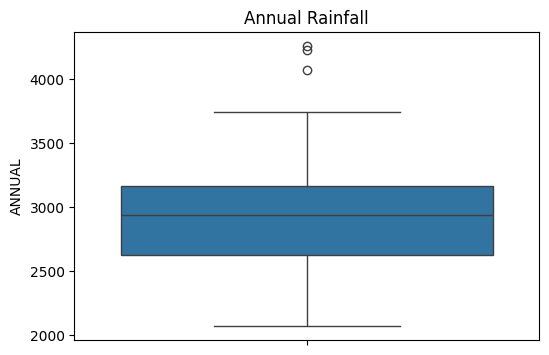

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(y=df['ANNUAL'])
plt.title("Annual Rainfall")
plt.show()

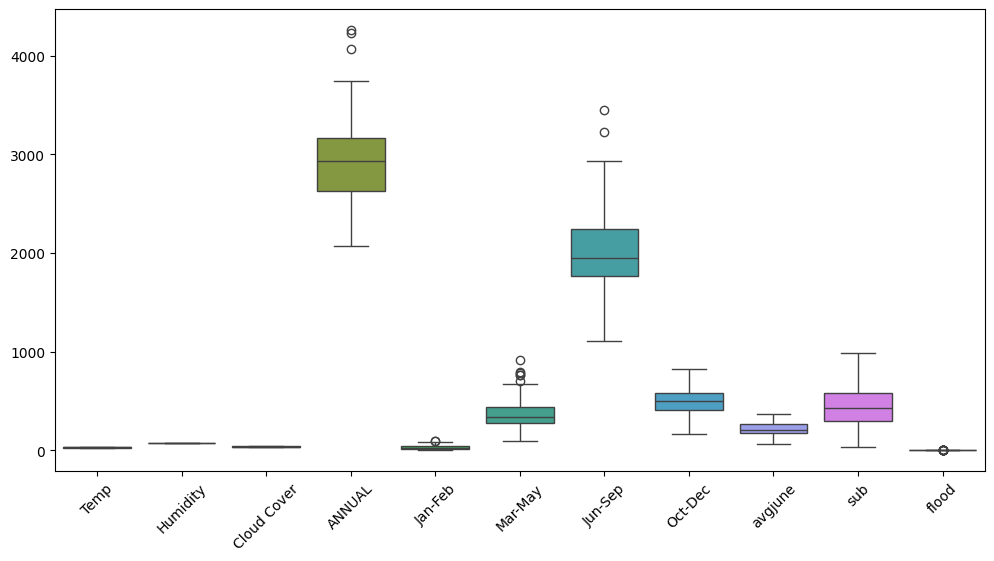

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.xticks(rotation=45)
plt.show()

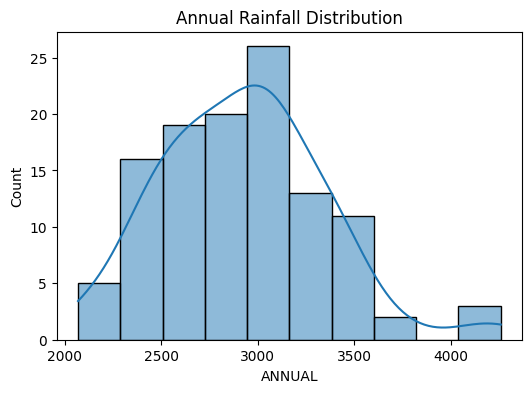

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['ANNUAL'], kde=True)
plt.title("Annual Rainfall Distribution")
plt.show()

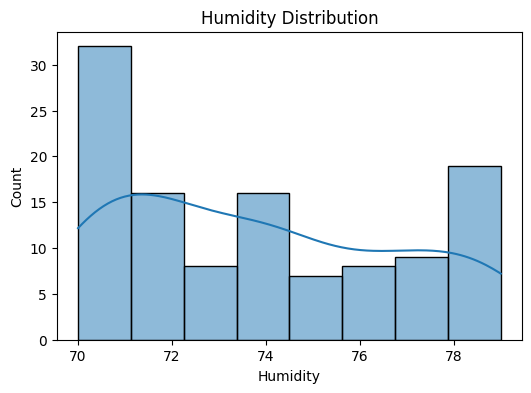

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Humidity'], kde=True)
plt.title("Humidity Distribution")
plt.show()

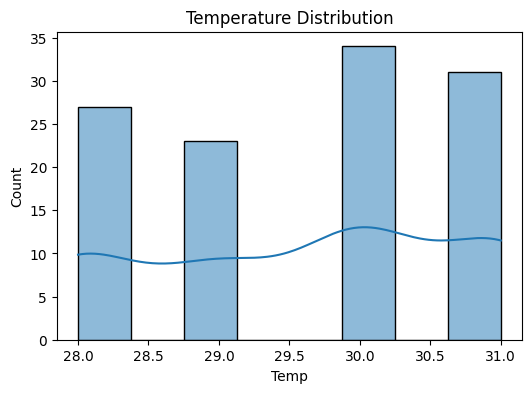

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Temp'], kde=True)
plt.title("Temperature Distribution")
plt.show()

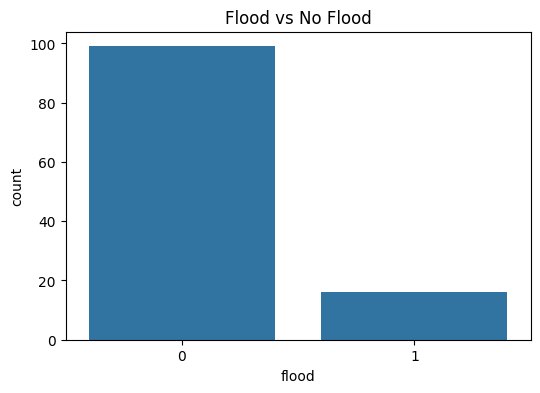

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='flood', data=df)
plt.title("Flood vs No Flood")
plt.show()

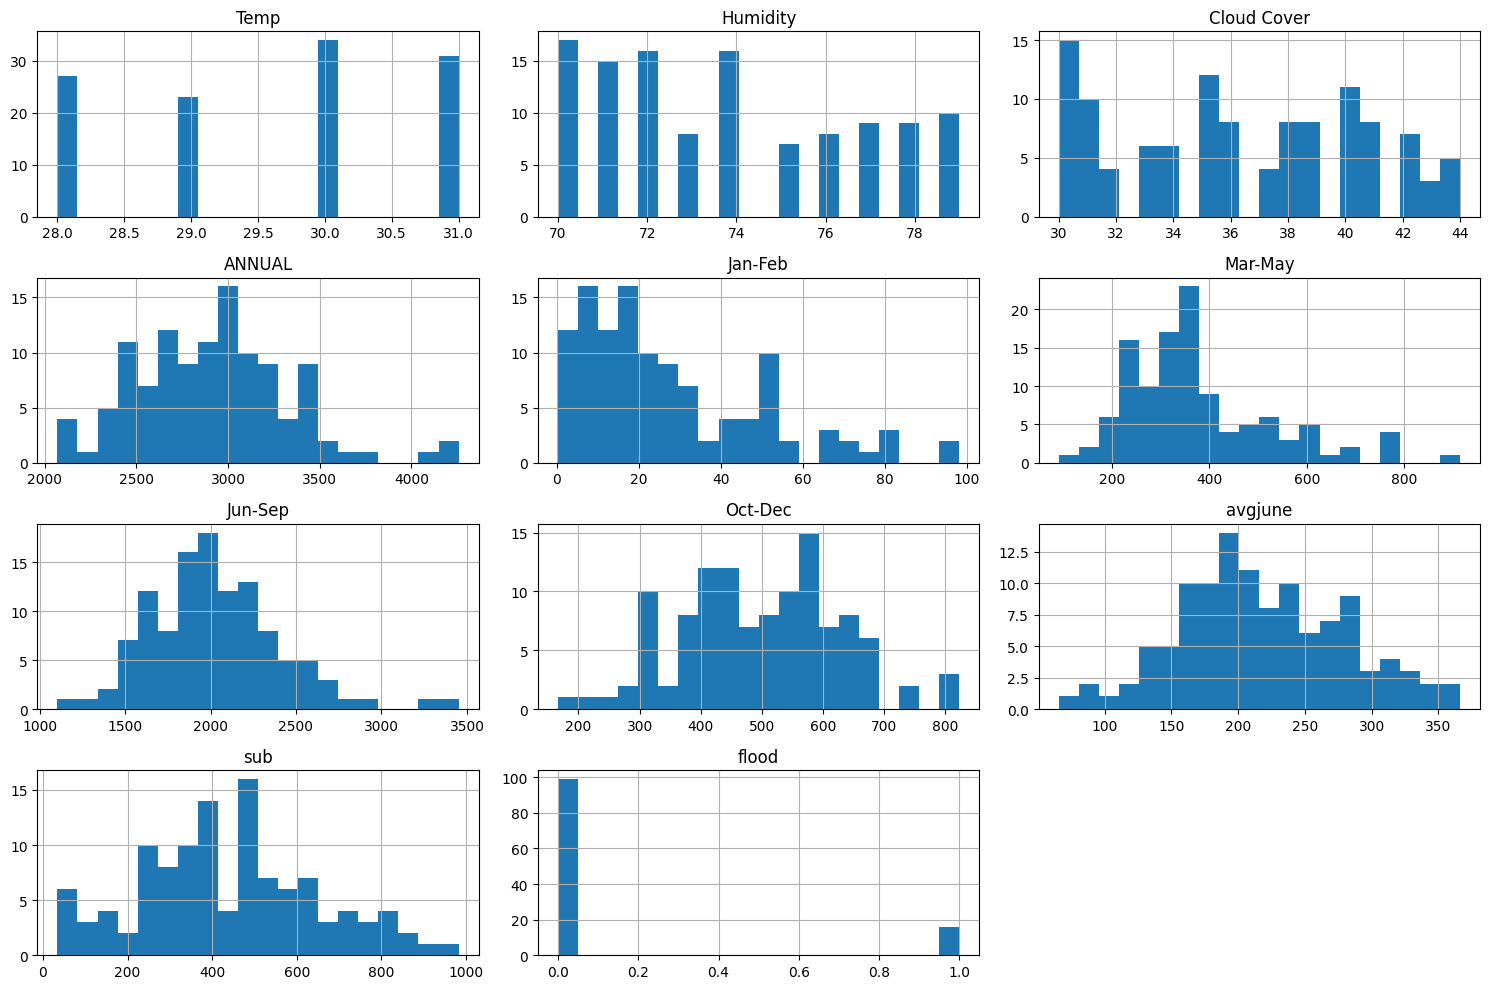

In [ ]:
df.hist(figsize=(15,10), bins=20)
plt.tight_layout()
plt.show()

In [ ]:
df.dtypes

Temp             int64
Humidity         int64
Cloud Cover      int64
ANNUAL         float64
Jan-Feb        float64
Mar-May        float64
Jun-Sep        float64
Oct-Dec        float64
avgjune        float64
sub            float64
flood            int64
dtype: object

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.isnull().sum()

Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

In [ ]:
df.describe()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
count,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000,115.000000
mean,29.600000,73.852174,36.286957,2925.487826,27.739130,377.253913,2022.840870,497.636522,218.100870,439.801739,0.139130
std,1.122341,2.947623,4.330158,422.112193,22.361032,151.091850,386.254397,129.860643,62.547597,210.438813,0.347597
min,28.000000,70.000000,30.000000,2068.800000,0.300000,89.900000,1104.300000,166.600000,65.600000,34.200000,0.000000
25%,29.000000,71.000000,32.500000,2627.900000,10.250000,276.750000,1768.850000,407.450000,179.666667,295.000000,0.000000
50%,30.000000,74.000000,36.000000,2937.500000,20.500000,342.000000,1948.700000,501.500000,211.033333,430.600000,0.000000
75%,31.000000,76.000000,40.000000,3164.100000,41.600000,442.300000,2242.900000,584.550000,263.833333,577.650000,0.000000
max,31.000000,79.000000,44.000000,4257.800000,98.100000,915.200000,3451.300000,823.300000,366.066667,982.700000,1.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [ ]:
df.columns

Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

In [ ]:
df.shape

(115, 11)

In [ ]:
df.head()

,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.6,73.4,386.2,2122.8,666.1,274.866667,649.9,0
1,28,75,40,3326.6,9.3,275.7,2403.4,638.2,130.300000,256.4,1
2,28,75,42,3271.2,21.7,336.3,2343.0,570.1,186.200000,308.9,0
3,29,71,44,3129.7,26.7,339.4,2398.2,365.3,366.066667,862.5,0
4,31,74,40,2741.6,23.4,378.5,1881.5,458.1,283.400000,586.9,0


In [ ]:
df = pd.read_excel("../datasets/flood_dataset.xlsx")

In [ ]:
# Numerical Computing
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

In [ ]:
pred = xgb_model.predict(X_test)

print("Predictions :", pred)
print("Actual      :", y_test.values)

NameError: name 'xgb_model' is not defined